# Clasificación de Géneros de Escarabajos con ResNet50

Este notebook implementa un modelo de clasificación de géneros de escarabajos usando una red neuronal convolucional preentrenada (ResNet50) y PyTorch.

## Estructura del Proyecto
- Dataset: 32 géneros de escarabajos
- Imágenes: `cropped_beetles/images/genero_n/`
- Etiquetas: `cropped_beetles/labels/genero_n/`

In [10]:
# Configuración del entorno para evitar problemas de compatibilidad
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Verificar versiones instaladas
try:
    import numpy as np
    import torch
    import scipy
    import sklearn
    
    print(f"NumPy version: {np.__version__}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"SciPy version: {scipy.__version__}")
    print(f"Scikit-learn version: {sklearn.__version__}")
    
    if hasattr(torch, 'cuda') and torch.cuda.is_available():
        print(f"CUDA available: {torch.cuda.is_available()}")
        print(f"CUDA version: {torch.version.cuda}")
        
    # Verificar compatibilidad de versiones
    import pkg_resources
    from packaging import version
    
    np_version = version.parse(np.__version__)
    min_np_version = version.parse("1.25.2")
    max_np_version = version.parse("2.6.0")
    
    if np_version < min_np_version or np_version >= max_np_version:
        print(f"\n⚠️ ADVERTENCIA: La versión actual de NumPy ({np.__version__}) no es compatible con SciPy.")
        print(f"   Se recomienda una versión entre 1.25.2 y 2.6.0\n")
        print("Comandos para actualizar (ejecutar en terminal):")
        print("conda activate beetles")
        print("conda install numpy=1.25.2 -y")
except ImportError as e:
    print(f"Error al importar: {e}")
    print("\nEs posible que necesites ejecutar estos comandos en una terminal:")
    print("conda activate beetles")
    print("conda install numpy=1.25.2 scipy scikit-learn -y")

NumPy version: 1.25.2
PyTorch version: 2.5.1
SciPy version: 1.16.0
Scikit-learn version: 1.7.2
CUDA available: True
CUDA version: 12.1


In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score


In [12]:

# Configurar la semilla para reproducibilidad
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Verificar si GPU está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")

Utilizando dispositivo: cuda


Total de clases: 32
Total de imágenes: 5310


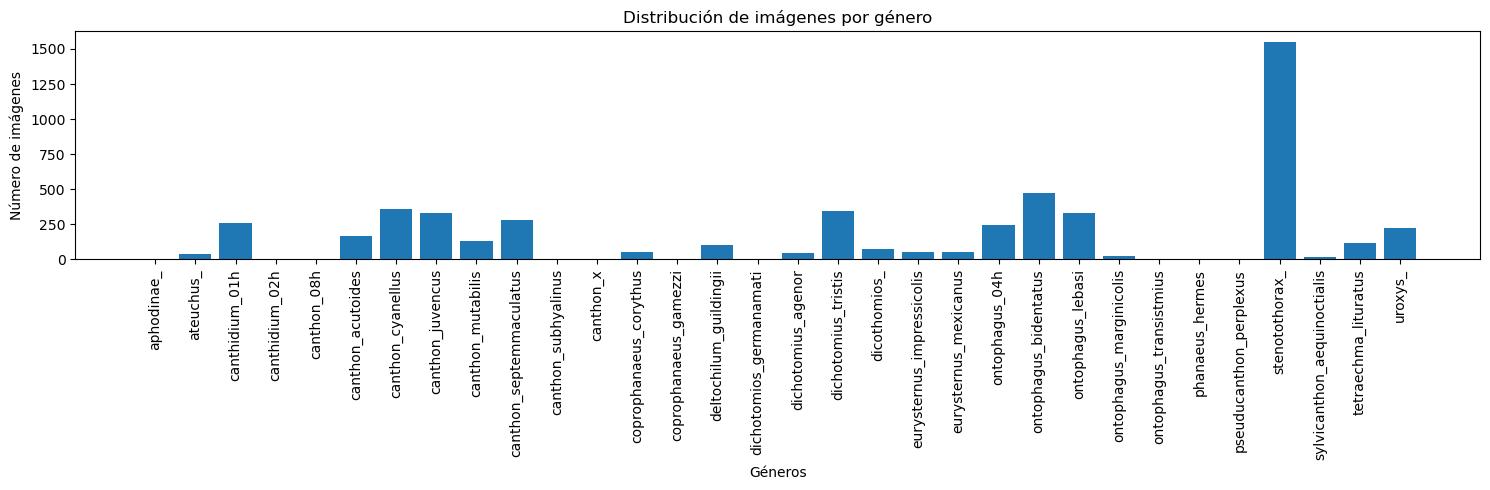

In [13]:
# Definir la clase para nuestro conjunto de datos de escarabajos
class BeetleDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Función para cargar las imágenes y etiquetas
def load_dataset(data_dir='cropped_beetles/images'):
    image_paths = []
    labels = []
    class_names = []
    
    # Obtener las carpetas de géneros (clases)
    for class_idx, genus_folder in enumerate(sorted(os.listdir(data_dir))):
        genus_path = os.path.join(data_dir, genus_folder)
        
        if os.path.isdir(genus_path):
            class_names.append(genus_folder)
            
            # Obtener todas las imágenes de cada género
            for img_file in os.listdir(genus_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(genus_path, img_file)
                    image_paths.append(img_path)
                    labels.append(class_idx)
    
    print(f"Total de clases: {len(class_names)}")
    print(f"Total de imágenes: {len(image_paths)}")
    
    return image_paths, labels, class_names

# Cargar el dataset
image_paths, labels, class_names = load_dataset()

# Mostrar la distribución de clases
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(15, 5))
plt.bar([class_names[i] for i in unique_labels], counts)
plt.xticks(rotation=90)
plt.xlabel('Géneros')
plt.ylabel('Número de imágenes')
plt.title('Distribución de imágenes por género')
plt.tight_layout()
plt.show()

# Definir transformaciones para preprocesamiento de imágenes
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
# Configuración para múltiples entrenamientos
NUM_RUNS = 3  # Número de entrenamientos a realizar
RANDOM_SEEDS = [42, 123, 456]  # Semillas diferentes para cada entrenamiento

# Diccionario para almacenar resultados de todos los entrenamientos
all_results = {
    'train_losses': [],
    'val_losses': [],
    'train_accs': [],
    'val_accs': [],
    'true_labels': [],
    'predictions': [],
    'models': [],
    'class_reports': []
}

print(f"Se realizarán {NUM_RUNS} entrenamientos con diferentes divisiones train/val")
print(f"Semillas aleatorias: {RANDOM_SEEDS}\n")


Se realizarán 3 entrenamientos con diferentes divisiones train/val
Semillas aleatorias: [42, 123, 456]



In [15]:
# Crear el modelo ResNet50 preentrenado y modificar la capa final
def create_model(num_classes):
    # Cargar el modelo preentrenado
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # Congelar todos los parámetros
    for param in model.parameters():
        param.requires_grad = False
    
    # Obtener el número de características del último layer
    num_ftrs = model.fc.in_features
    
    # Reemplazar el último layer completamente conectado
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    
    # Descongelar las últimas capas para fine-tuning
    for child in list(model.children())[-3:]:
        for param in child.parameters():
            param.requires_grad = True
            
    return model

# Crear el modelo
num_classes = len(class_names)
model = create_model(num_classes)
model = model.to(device)

# Mostrar la arquitectura del modelo
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Ciclo de Entrenamientos Múltiples

Ahora ejecutaremos los 3 entrenamientos con diferentes divisiones train/val

In [16]:
# Preservar las variables originales para poder usarlas en cada iteración
original_image_paths = image_paths.copy()
original_labels = labels.copy()

print(f"Variables originales preservadas:")
print(f"  - {len(original_image_paths)} rutas de imágenes")
print(f"  - {len(original_labels)} etiquetas")


Variables originales preservadas:
  - 5310 rutas de imágenes
  - 5310 etiquetas


In [17]:
for run_idx in range(NUM_RUNS):
    print(f"\n{'='*80}")
    print(f"ENTRENAMIENTO {run_idx + 1}/{NUM_RUNS} - Semilla: {RANDOM_SEEDS[run_idx]}")
    print(f"{'='*80}\n")
    
    # Configurar semilla para esta ejecución
    seed = RANDOM_SEEDS[run_idx]
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    # Dividir el dataset con la nueva semilla usando las variables ORIGINALES
    X_train, X_val, y_train, y_val = train_test_split(
        original_image_paths, original_labels, test_size=0.2, random_state=seed, stratify=original_labels
    )
    
    print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")
    print(f"Tamaño del conjunto de validación: {len(X_val)}")
    
    # Calcular los pesos de las clases para manejar el desbalance
    class_counts = np.bincount(y_train)
    class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    
    # Crear pesos de muestreo para cada muestra de entrenamiento
    sample_weights = [class_weights[label] for label in y_train]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    # Crear datasets
    train_dataset = BeetleDataset(X_train, y_train, transform=transform_train)
    val_dataset = BeetleDataset(X_val, y_val, transform=transform_val)
    
    # Crear data loaders
    train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    
    # Crear nuevo modelo para este entrenamiento
    model = create_model(num_classes)
    model = model.to(device)
    
    # Definir la función de pérdida y el optimizador
    class_weights_tensor = class_weights.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    
    # Usar un planificador de tasa de aprendizaje
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1, verbose=True)
    
    # Función para entrenar el modelo
    def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=100):
        train_losses = []
        val_losses = []
        train_accs = []
        val_accs = []
        
        best_val_acc = 0.0
        
        for epoch in range(num_epochs):
            # Fase de entrenamiento
            model.train()
            running_loss = 0.0
            running_corrects = 0
            total = 0
            
            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total += labels.size(0)
                
            epoch_loss = running_loss / total
            epoch_acc = running_corrects.double() / total
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
            
            # Fase de validación
            model.eval()
            running_loss = 0.0
            running_corrects = 0
            total = 0
            
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                    total += labels.size(0)
                    
            val_loss = running_loss / total
            val_acc = running_corrects.double() / total
            val_losses.append(val_loss)
            val_accs.append(val_acc.item())
            
            scheduler.step(val_loss)
            
            print(f'Época {epoch+1}/{num_epochs}: '
                  f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), f'best_beetle_model_run_{run_idx+1}.pth')
                print(f'Nuevo mejor modelo guardado con precisión: {val_acc:.4f}')
        
        model.load_state_dict(torch.load(f'best_beetle_model_run_{run_idx+1}.pth'))
        
        return model, train_losses, val_losses, train_accs, val_accs
    
    # Entrenar el modelo
    model, train_losses, val_losses, train_accs, val_accs = train_model(
        model, criterion, optimizer, scheduler, train_loader, val_loader
    )
    
    # Evaluar el modelo
    model.eval()
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    # Calcular métricas
    accuracy = accuracy_score(true_labels, predictions)
    
    # Generar classification report
    unique_labels = np.unique(true_labels)
    present_class_names = [class_names[i] for i in unique_labels]
    class_report = classification_report(true_labels, predictions, 
                                        labels=unique_labels,
                                        target_names=present_class_names)
    
    print(f"\n--- Resultados del Entrenamiento {run_idx + 1} ---")
    print(f"Accuracy final: {accuracy:.4f}")
    print(f"Mejor Val Acc durante entrenamiento: {max(val_accs):.4f}")
    
    # Guardar resultados
    all_results['train_losses'].append(train_losses)
    all_results['val_losses'].append(val_losses)
    all_results['train_accs'].append(train_accs)
    all_results['val_accs'].append(val_accs)
    all_results['true_labels'].append(true_labels)
    all_results['predictions'].append(predictions)
    all_results['models'].append(model)
    all_results['class_reports'].append(class_report)

print(f"\n{'='*80}")
print(f"TODOS LOS ENTRENAMIENTOS COMPLETADOS")
print(f"{'='*80}\n")



ENTRENAMIENTO 1/3 - Semilla: 42

Tamaño del conjunto de entrenamiento: 4248
Tamaño del conjunto de validación: 1062


c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Época 1/100: Train Loss: 0.6224, Train Acc: 0.3242, Val Loss: 2.9908, Val Acc: 0.0264
Nuevo mejor modelo guardado con precisión: 0.0264
Época 2/100: Train Loss: 0.1062, Train Acc: 0.5181, Val Loss: 1.7344, Val Acc: 0.1083
Nuevo mejor modelo guardado con precisión: 0.1083
Época 2/100: Train Loss: 0.1062, Train Acc: 0.5181, Val Loss: 1.7344, Val Acc: 0.1083
Nuevo mejor modelo guardado con precisión: 0.1083
Época 3/100: Train Loss: 0.0580, Train Acc: 0.6469, Val Loss: 1.2801, Val Acc: 0.3089
Nuevo mejor modelo guardado con precisión: 0.3089
Época 3/100: Train Loss: 0.0580, Train Acc: 0.6469, Val Loss: 1.2801, Val Acc: 0.3089
Nuevo mejor modelo guardado con precisión: 0.3089
Época 4/100: Train Loss: 0.0361, Train Acc: 0.7429, Val Loss: 0.9665, Val Acc: 0.4313
Nuevo mejor modelo guardado con precisión: 0.4313
Época 4/100: Train Loss: 0.0361, Train Acc: 0.7429, Val Loss: 0.9665, Val Acc: 0.4313
Nuevo mejor modelo guardado con precisión: 0.4313
Época 5/100: Train Loss: 0.0237, Train Acc: 0.81

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_30340\938821973.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_beetle_model_


--- Resultados del Entrenamiento 1 ---
Accuracy final: 0.8936
Mejor Val Acc durante entrenamiento: 0.8936

ENTRENAMIENTO 2/3 - Semilla: 123

Tamaño del conjunto de entrenamiento: 4248
Tamaño del conjunto de validación: 1062


...

c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Época 1/100: Train Loss: 0.5634, Train Acc: 0.3213, Val Loss: 3.0815, Val Acc: 0.0273
Nuevo mejor modelo guardado con precisión: 0.0273
Época 2/100: Train Loss: 0.1299, Train Acc: 0.4953, Val Loss: 1.7576, Val Acc: 0.0753
Nuevo mejor modelo guardado con precisión: 0.0753
Época 2/100: Train Loss: 0.1299, Train Acc: 0.4953, Val Loss: 1.7576, Val Acc: 0.0753
Nuevo mejor modelo guardado con precisión: 0.0753
Época 3/100: Train Loss: 0.0702, Train Acc: 0.6123, Val Loss: 1.3638, Val Acc: 0.2476
Nuevo mejor modelo guardado con precisión: 0.2476
Época 3/100: Train Loss: 0.0702, Train Acc: 0.6123, Val Loss: 1.3638, Val Acc: 0.2476
Nuevo mejor modelo guardado con precisión: 0.2476
Época 4/100: Train Loss: 0.0457, Train Acc: 0.7069, Val Loss: 1.0985, Val Acc: 0.3512
Nuevo mejor modelo guardado con precisión: 0.3512
Época 4/100: Train Loss: 0.0457, Train Acc: 0.7069, Val Loss: 1.0985, Val Acc: 0.3512
Nuevo mejor modelo guardado con precisión: 0.3512
Época 5/100: Train Loss: 0.0267, Train Acc: 0.79

C:\Users\Estudiantes\AppData\Local\Temp\ipykernel_30340\938821973.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_beetle_model_


--- Resultados del Entrenamiento 3 ---
Accuracy final: 0.8051
Mejor Val Acc durante entrenamiento: 0.8051

TODOS LOS ENTRENAMIENTOS COMPLETADOS



c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Estudiantes\miniconda3\envs\beetles\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

## Comparación de Resultados entre los 3 Entrenamientos

A continuación se presentan las comparaciones de los 3 entrenamientos realizados

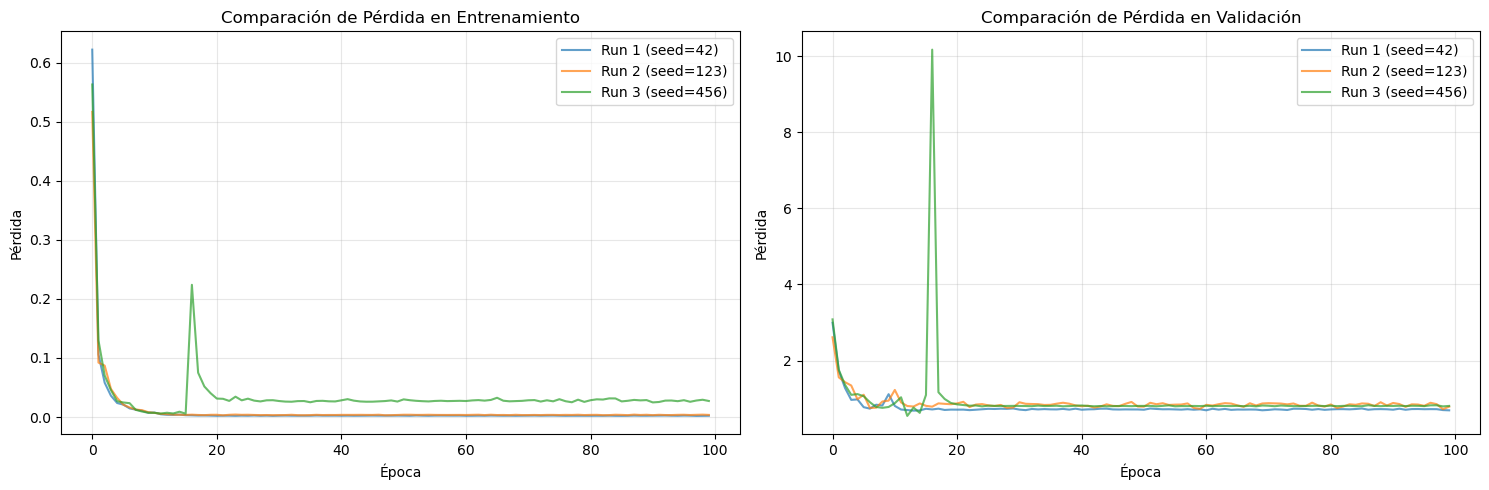

In [18]:
# Comparación de Curvas de Pérdida (Loss)
plt.figure(figsize=(15, 5))

# Pérdida de Entrenamiento
plt.subplot(1, 2, 1)
for i in range(NUM_RUNS):
    plt.plot(all_results['train_losses'][i], label=f'Run {i+1} (seed={RANDOM_SEEDS[i]})', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Comparación de Pérdida en Entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)

# Pérdida de Validación
plt.subplot(1, 2, 2)
for i in range(NUM_RUNS):
    plt.plot(all_results['val_losses'][i], label=f'Run {i+1} (seed={RANDOM_SEEDS[i]})', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Comparación de Pérdida en Validación')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


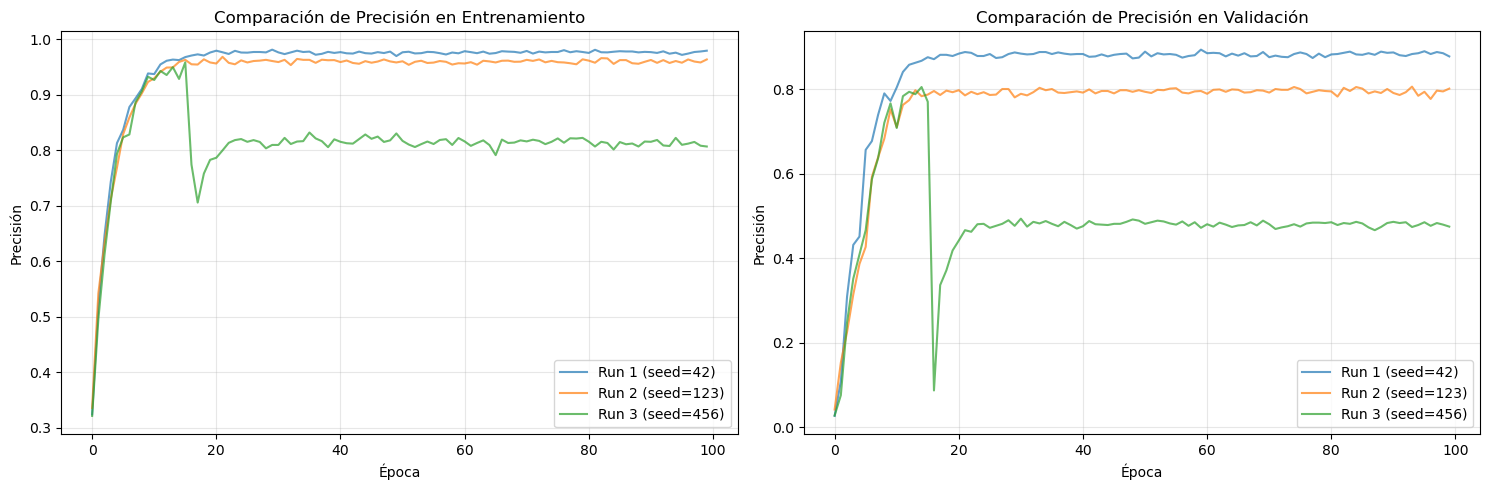

In [19]:
# Comparación de Curvas de Precisión (Accuracy)
plt.figure(figsize=(15, 5))

# Precisión de Entrenamiento
plt.subplot(1, 2, 1)
for i in range(NUM_RUNS):
    plt.plot(all_results['train_accs'][i], label=f'Run {i+1} (seed={RANDOM_SEEDS[i]})', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Comparación de Precisión en Entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)

# Precisión de Validación
plt.subplot(1, 2, 2)
for i in range(NUM_RUNS):
    plt.plot(all_results['val_accs'][i], label=f'Run {i+1} (seed={RANDOM_SEEDS[i]})', alpha=0.7)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Comparación de Precisión en Validación')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
# Resumen de Métricas Finales para cada Entrenamiento
print("="*80)
print("RESUMEN DE MÉTRICAS FINALES")
print("="*80)

summary_data = {
    'Entrenamiento': [],
    'Semilla': [],
    'Mejor Train Acc': [],
    'Mejor Val Acc': [],
    'Mejor Train Loss': [],
    'Mejor Val Loss': []
}

for i in range(NUM_RUNS):
    summary_data['Entrenamiento'].append(f'Run {i+1}')
    summary_data['Semilla'].append(RANDOM_SEEDS[i])
    summary_data['Mejor Train Acc'].append(f"{max(all_results['train_accs'][i]):.4f}")
    summary_data['Mejor Val Acc'].append(f"{max(all_results['val_accs'][i]):.4f}")
    summary_data['Mejor Train Loss'].append(f"{min(all_results['train_losses'][i]):.4f}")
    summary_data['Mejor Val Loss'].append(f"{min(all_results['val_losses'][i]):.4f}")

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n")


RESUMEN DE MÉTRICAS FINALES
Entrenamiento  Semilla Mejor Train Acc Mejor Val Acc Mejor Train Loss Mejor Val Loss
        Run 1       42          0.9809        0.8936           0.0019         0.6836
        Run 2      123          0.9680        0.8060           0.0029         0.7222
        Run 3      456          0.9581        0.8051           0.0057         0.5451




In [21]:
# Classification Reports de los 3 Entrenamientos
print("="*80)
print("CLASSIFICATION REPORTS COMPARATIVOS")
print("="*80)

for i in range(NUM_RUNS):
    print(f"\n{'='*80}")
    print(f"ENTRENAMIENTO {i+1} (Semilla: {RANDOM_SEEDS[i]})")
    print(f"{'='*80}")
    print(all_results['class_reports'][i])


CLASSIFICATION REPORTS COMPARATIVOS

ENTRENAMIENTO 1 (Semilla: 42)
                             precision    recall  f1-score   support

                 aphodinae_       0.00      0.00      0.00         1
                  ateuchus_       0.88      0.88      0.88         8
             canthidium_01h       0.85      0.86      0.85        51
          canthon_acutoides       0.81      0.85      0.83        34
          canthon_cyanellus       0.94      0.92      0.93        72
           canthon_juvencus       0.88      0.98      0.93        66
          canthon_mutabilis       0.75      0.69      0.72        26
    canthon_septemmaculatus       0.98      0.91      0.94        56
        canthon_subhyalinus       1.00      1.00      1.00         1
                  canthon_x       1.00      1.00      1.00         1
     coprophanaeus_corythus       1.00      0.80      0.89        10
      coprophanaeus_gamezzi       1.00      1.00      1.00         1
     deltochilum_guildingii       1

In [ ]:
# Guardar el modelo entrenado
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'class_names': class_names
# }, 'beetle_classifier_resnet50.pth')

print("Modelo guardado como 'beetle_classifier_resnet50.pth'")

Modelo guardado como 'beetle_classifier_resnet50.pth'


## Función para Predicción

A continuación se muestra cómo puedes utilizar el modelo entrenado para hacer predicciones en nuevas imágenes:

In [22]:
# Función para hacer predicciones con una nueva imagen
def predict_image(image_path, model, class_names):
    # Cargar y preprocesar la imagen
    img = Image.open(image_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = transform(img).unsqueeze(0)
    
    # Mover al dispositivo correcto
    img_tensor = img_tensor.to(device)
    
    # Modo de evaluación
    model.eval()
    
    # Hacer predicción
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        
        # Calcular probabilidades con softmax
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probabilities, 3, dim=1)
        
    # Mostrar imagen y predicciones
    plt.figure(figsize=(8, 10))
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.title(f'Predicción: {class_names[preds.item()]}')
    plt.axis('off')
    
    # Visualizar las 3 clases con mayor probabilidad
    plt.subplot(2, 1, 2)
    top_probs = top_probs.squeeze().cpu().numpy()
    top_indices = top_indices.squeeze().cpu().numpy()
    
    top_classes = [class_names[i] for i in top_indices]
    
    plt.barh(range(3), top_probs, color='skyblue')
    plt.yticks(range(3), top_classes)
    plt.xlabel('Probabilidad')
    plt.title('Top 3 Predicciones')
    plt.tight_layout()
    plt.show()
    
    return preds.item(), probabilities.squeeze().cpu().numpy()

# Ejemplo de cómo usar la función de predicción (descomenta para probar)
# nueva_imagen = "ruta/a/nueva/imagen.jpg"
# pred_class, probabilities = predict_image(nueva_imagen, model, class_names)